In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

Task 1: Data Loading, Cleaning & Exploratory Data Analysis


In [2]:
df = pd.read_csv('adult.csv')

print('Dataset Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)

df.head()

Dataset Shape: (48842, 15)

Data Types:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

 Handle Missing Values

In [4]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [5]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [6]:
df.dropna(inplace=True)
print('Shape after removing missing values:', df.shape)

Shape after removing missing values: (45222, 15)


In [7]:
df.drop(columns=['fnlwgt', 'education'], inplace=True)
print('Shape after dropping columns:', df.shape)

Shape after dropping columns: (45222, 13)


In [8]:
df['income'] = (df['income'] == '>50K').astype(int)

print(df['income'].value_counts())
print("\nPercentage:")
print(df['income'].value_counts(normalize=True) * 100)

income
0    34014
1    11208
Name: count, dtype: int64

Percentage:
income
0    75.215603
1    24.784397
Name: proportion, dtype: float64


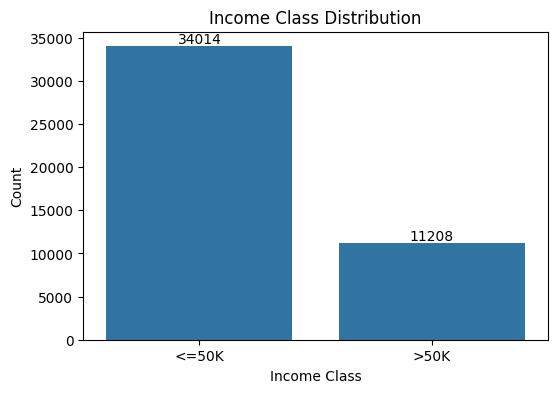

In [9]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x='income', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Income Class Distribution')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['<=50K', '>50K'])
plt.show()

Exploratory visualisations

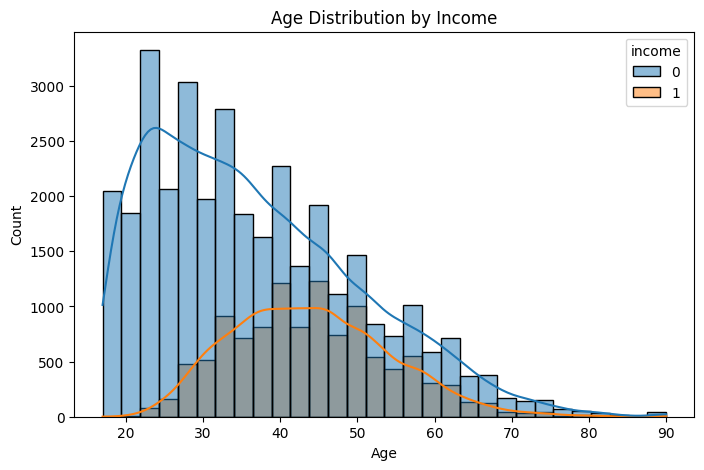

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,x='age',hue='income',bins=30,kde=True)

plt.title('Age Distribution by Income')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [11]:
df.columns

Index(['age', 'workclass', 'educational-num', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

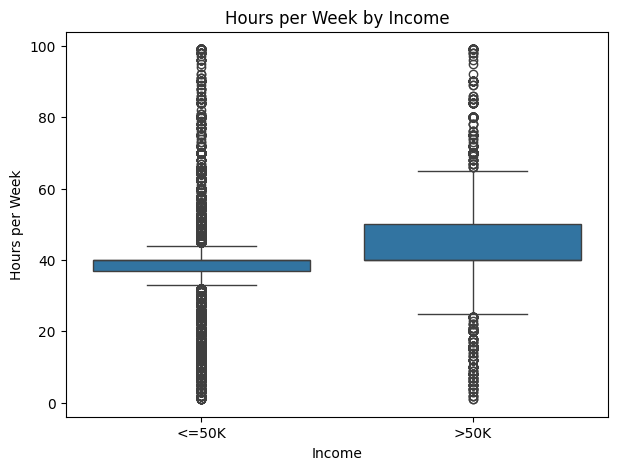

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df,x='income',y='hours-per-week')

plt.title('Hours per Week by Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.xticks([0, 1], ['<=50K', '>50K'])
plt.show()

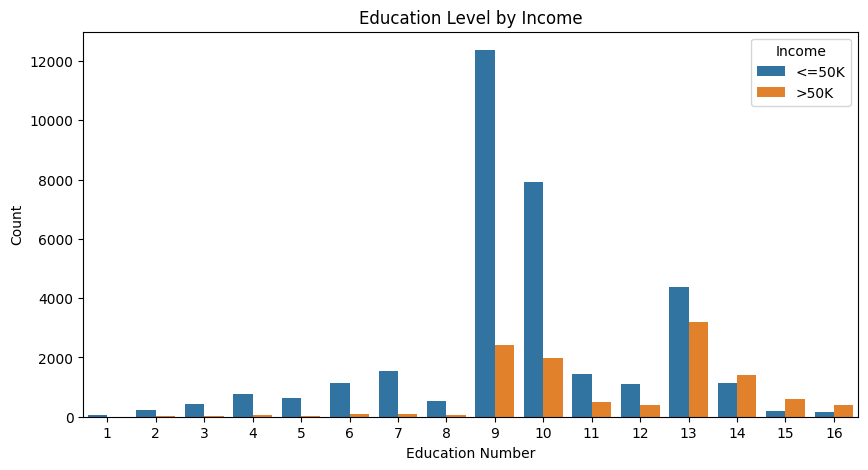

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df,x='educational-num',hue='income')

plt.title('Education Level by Income')
plt.xlabel('Education Number')
plt.ylabel('Count')
plt.legend(title='Income', labels=['<=50K', '>50K'])
plt.show()

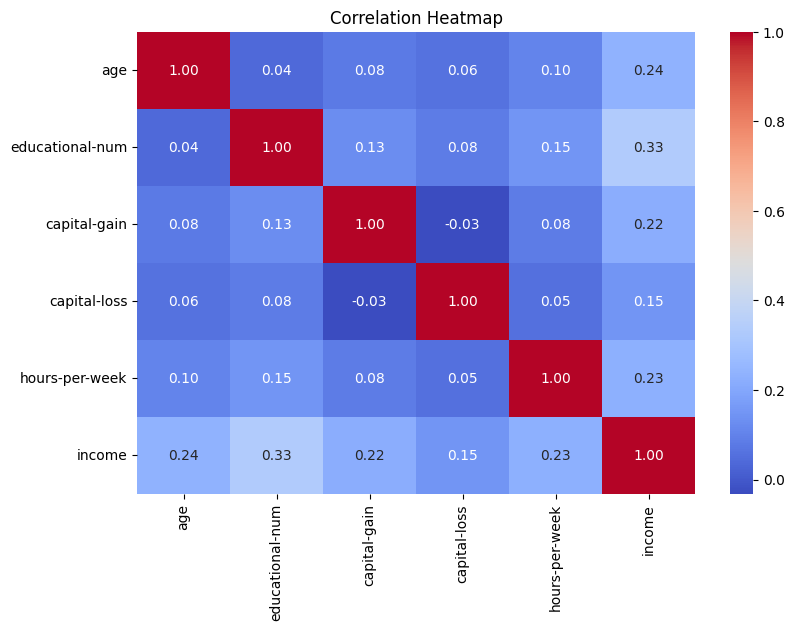

In [14]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(),annot=True,fmt='.2f',cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Encode categoricals & scale numerics

In [15]:
X = df.drop('income', axis=1)
y = df['income']

numeric_cols = ['age','educational-num','capital-gain','capital-loss','hours-per-week']

X = pd.get_dummies(X, drop_first=True)
print("Number of features after One-Hot Encoding:", X.shape[1])

Number of features after One-Hot Encoding: 80


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [17]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [18]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [19]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

print("\nTraining class ratio:")
print(y_train.value_counts(normalize=True))
print("\nTesting class ratio:")
print(y_test.value_counts(normalize=True))

X_train: (36177, 80)
X_test : (9045, 80)
y_train: (36177,)
y_test : (9045,)

Training class ratio:
income
0    0.752163
1    0.247837
Name: proportion, dtype: float64

Testing class ratio:
income
0    0.752128
1    0.247872
Name: proportion, dtype: float64


**Task 2: MLP Architecture — Baseline ANN**

In [20]:
def build_ann(
    input_dim,
    hidden_units=[128, 64],
    activation='relu',
    initializer='glorot_uniform',
    use_batch_norm=False,
    optimizer='adam',
    loss='binary_crossentropy'
):

    model = keras.Sequential()

    model.add(
        layers.Input(shape=(input_dim,))
    )

    for units in hidden_units:

        model.add(
            layers.Dense(
                units,
                kernel_initializer=initializer
            )
        )

        if use_batch_norm:
            model.add(layers.BatchNormalization())

        model.add(layers.Activation(activation))

    model.add(
        layers.Dense(
            1,
            activation='sigmoid'
        )
    )

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

 Baseline Model

In [21]:
model_base = build_ann(input_dim=X_train.shape[1])
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model

In [22]:
history_base = model_base.fit(X_train,y_train,epochs=50,batch_size=64,validation_split=0.1,verbose=1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8419 - loss: 0.3388 - val_accuracy: 0.8524 - val_loss: 0.3221
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.3143 - val_accuracy: 0.8516 - val_loss: 0.3206
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8549 - loss: 0.3106 - val_accuracy: 0.8519 - val_loss: 0.3205
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.3076 - val_accuracy: 0.8494 - val_loss: 0.3200
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8571 - loss: 0.3047 - val_accuracy: 0.8499 - val_loss: 0.3201
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.3020 - val_accuracy: 0.8496 - val_loss: 0.3204
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8606 - loss: 0.2994 - val_accuracy: 0.8494 - val_loss: 0.3205
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8617 - loss: 0.2968 - val_accuracy: 0.

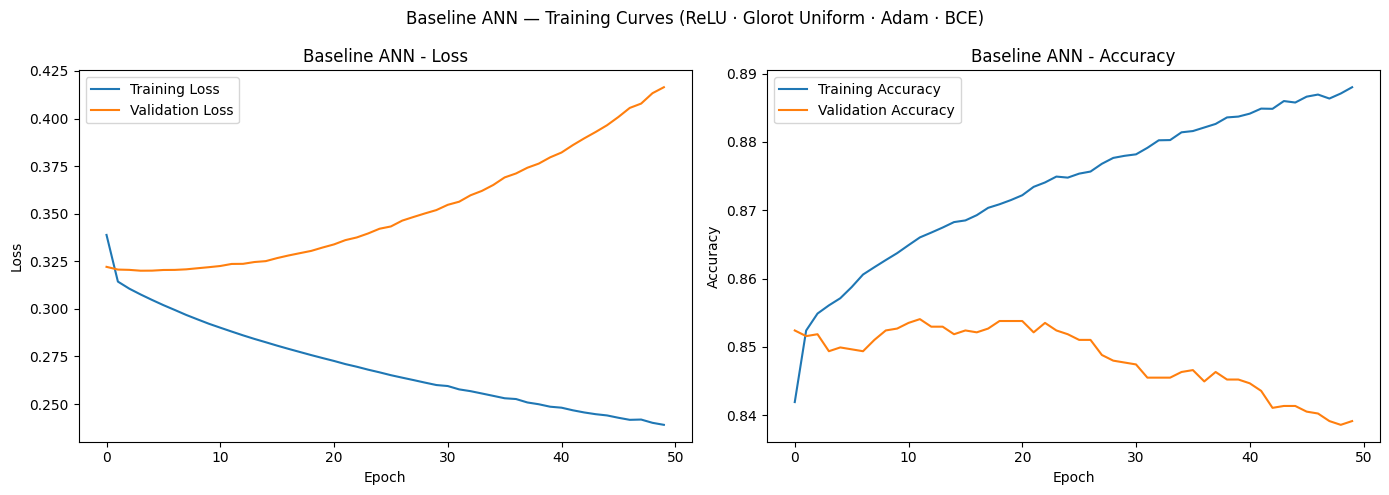

In [23]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history_base.history['loss'], label='Training Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')

plt.title('Baseline ANN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(history_base.history['accuracy'], label='Training Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')

plt.title('Baseline ANN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle(
    'Baseline ANN — Training Curves '
    '(ReLU · Glorot Uniform · Adam · BCE)'
)

plt.tight_layout()
plt.show()

 Evaluate the baseline with full metrics

In [24]:
y_pred_prob_base = model_base.predict(X_test).flatten()
y_pred_base = (y_pred_prob_base > 0.5).astype(int)
print(classification_report(y_test, y_pred_base))

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6803
           1       0.69      0.60      0.64      2242

    accuracy                           0.83      9045
   macro avg       0.78      0.75      0.77      9045
weighted avg       0.83      0.83      0.83      9045



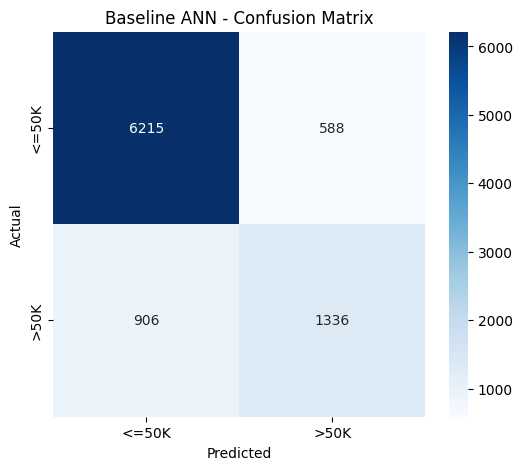

In [25]:
cm = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['<=50K', '>50K'],yticklabels=['<=50K', '>50K'])

plt.title('Baseline ANN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_precision = precision_score(y_test, y_pred_base)
baseline_recall = recall_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_pred_prob_base)

print('Accuracy :', baseline_acc)
print('Precision:', baseline_precision)
print('Recall   :', baseline_recall)
print('F1-score :', baseline_f1)
print('ROC-AUC  :', baseline_auc)

Accuracy : 0.8348258706467662
Precision: 0.6943866943866944
Recall   : 0.5958965209634255
F1-score : 0.6413826212193952
ROC-AUC  : 0.8819928514509853


**Task 3: Activation Functions — Comparison Experiment**

In [27]:
activations = ['relu', 'tanh', 'sigmoid', 'elu']

activation_models = {}
activation_histories = {}

for activation in activations:

    print("\nTraining:", activation.upper())

    model = build_ann(
        input_dim=X_train.shape[1],
        activation=activation
    )

    history = model.fit(X_train,y_train,epochs=50,batch_size=64,validation_split=0.1,verbose=0)

    activation_models[activation] = model
    activation_histories[activation] = history

    print("Final validation accuracy:",history.history['val_accuracy'][-1])


Training: RELU
Final validation accuracy: 0.8394140601158142

Training: TANH
Final validation accuracy: 0.8499170541763306

Training: SIGMOID
Final validation accuracy: 0.8546158075332642

Training: ELU
Final validation accuracy: 0.8576561808586121


In [28]:
activation_f1 = {}

for activation, model in activation_models.items():

    prob = model.predict(X_test, verbose=0).flatten()
    pred = (prob > 0.5).astype(int)

    score = f1_score(y_test, pred)
    activation_f1[activation] = score

    print(activation, "F1:", score)

relu F1: 0.6434238999759557
tanh F1: 0.670693404203914
sigmoid F1: 0.6746634026927785
elu F1: 0.6700705081449064


Activation comparison — 4-panel plot

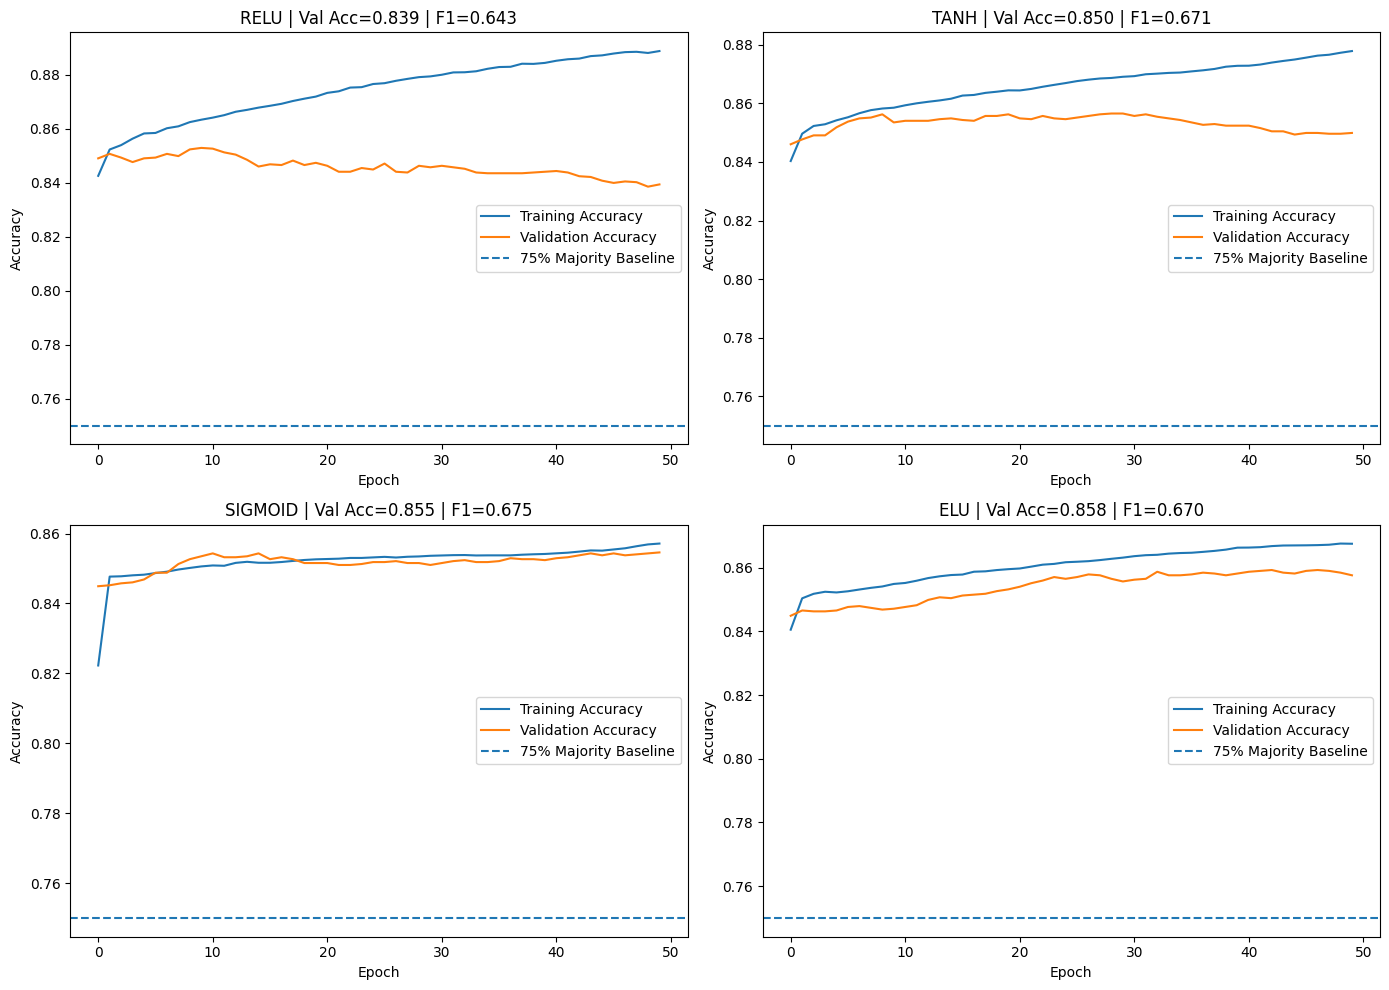

In [29]:
plt.figure(figsize=(14, 10))

for i, activation in enumerate(activations, 1):

    history = activation_histories[activation]

    plt.subplot(2, 2, i)

    plt.plot(
        history.history['accuracy'],
        label='Training Accuracy'
    )

    plt.plot(
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.axhline(
        0.75,
        linestyle='--',
        label='75% Majority Baseline'
    )

    val_acc = history.history['val_accuracy'][-1]
    f1 = activation_f1[activation]

    plt.title(
        f'{activation.upper()} | '
        f'Val Acc={val_acc:.3f} | F1={f1:.3f}'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

Dead ReLU Neuron Check

In [30]:
model_relu = activation_models['relu']

intermediate_model = keras.Model(
    inputs=model_relu.layers[0].input,
    outputs=model_relu.layers[2].output
)

activations_relu = intermediate_model.predict(
    X_test[:500],
    verbose=0
)

dead_fraction = np.mean(activations_relu == 0)

print("Dead Fraction:", dead_fraction)

Dead Fraction: 0.0


Gradient flow check — Sigmoid hidden layers

In [31]:
model_sigmoid = activation_models['sigmoid']

X_batch = tf.convert_to_tensor(
    X_train.iloc[:64].values,
    dtype=tf.float32
)

y_batch = tf.convert_to_tensor(
    y_train.iloc[:64].values.reshape(-1, 1),
    dtype=tf.float32
)

with tf.GradientTape() as tape:

    predictions = model_sigmoid(X_batch, training=True)

    loss_value = keras.losses.binary_crossentropy(
        y_batch,
        predictions
    )

    loss_value = tf.reduce_mean(loss_value)

gradients = tape.gradient(
    loss_value,
    model_sigmoid.trainable_weights
)

In [32]:
gradient_values = []

for grad in gradients:

    if grad is not None:
        gradient_values.append(
            np.mean(np.abs(grad.numpy()))
        )

gradient_values

[np.float32(0.0002472133),
 np.float32(0.00078118657),
 np.float32(0.00027042767),
 np.float32(0.0005684831),
 np.float32(0.0053724153),
 np.float32(0.0115536535)]

Task 4: Weight Initialization Techniques

In [33]:
initializers = ['glorot_uniform','glorot_normal','he_uniform','he_normal','zeros']

initializer_models = {}
initializer_histories = {}

for initializer in initializers:

    print("\nTraining:", initializer)

    model = build_ann(
        input_dim=X_train.shape[1],
        activation='relu',
        initializer=initializer
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    initializer_models[initializer] = model
    initializer_histories[initializer] = history

    print(
        "Final Validation Accuracy:",
        history.history['val_accuracy'][-1]
    )


Training: glorot_uniform
Final Validation Accuracy: 0.8424543738365173

Training: glorot_normal
Final Validation Accuracy: 0.8396904468536377

Training: he_uniform
Final Validation Accuracy: 0.8416252136230469

Training: he_normal
Final Validation Accuracy: 0.832504153251648

Training: zeros
Final Validation Accuracy: 0.7526257634162903


Convergence speed comparison plot

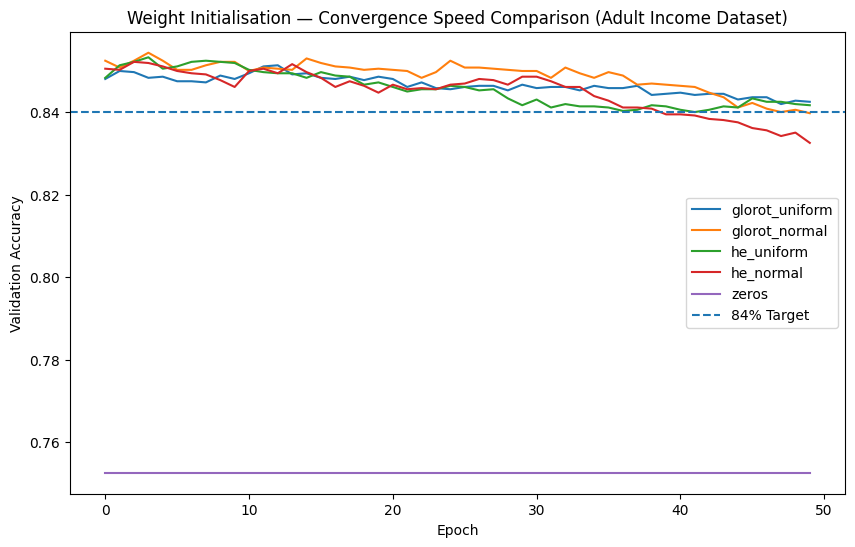

In [34]:
plt.figure(figsize=(10, 6))

for initializer, history in initializer_histories.items():

    plt.plot(
        history.history['val_accuracy'],
        label=initializer
    )

plt.axhline(
    0.84,
    linestyle='--',
    label='84% Target'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.title(
    'Weight Initialisation — Convergence Speed Comparison '
    '(Adult Income Dataset)'
)

plt.legend()
plt.show()

**Task 5: Loss Functions**

Binary Cross-Entropy is appropriate for binary classification because the output is interpreted as the probability of the positive class.

BCE strongly penalizes confident incorrect predictions and corresponds to the negative log-likelihood of a Bernoulli probability distribution.

 - MSE as classification loss — wrong tool experiment

In [35]:
model_mse = build_ann(
    input_dim=X_train.shape[1],
    activation='relu',
    initializer='he_normal',
    loss='mean_squared_error'
)

history_mse = model_mse.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

Weighted Binary Cross-Entropy — handling class imbalance

In [36]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {
    0: weights[0],
    1: weights[1]
}

print(class_weight_dict)

{0: np.float64(0.6647495498144133), 1: np.float64(2.0174548293553425)}


In [37]:
model_wbce = build_ann(
    input_dim=X_train.shape[1],
    activation='relu',
    initializer='he_normal',
    loss='binary_crossentropy'
)

history_wbce = model_wbce.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=0
)

wbce_prob = model_wbce.predict(X_test, verbose=0).flatten()
wbce_pred = (wbce_prob > 0.5).astype(int)

print(classification_report(y_test, wbce_pred))

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      6803
           1       0.56      0.81      0.66      2242

    accuracy                           0.80      9045
   macro avg       0.74      0.80      0.76      9045
weighted avg       0.84      0.80      0.81      9045



 Focal Loss — advanced imbalance handling

In [38]:
def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred,1e-7,1 - 1e-7)

        bce = (-y_true * tf.math.log(y_pred)-(1 - y_true) * tf.math.log(1 - y_pred))
        weight = (alpha * y_true * (1 - y_pred) ** gamma+(1 - alpha) * (1 - y_true) * y_pred ** gamma)
        return tf.reduce_mean(weight * bce)

    return loss

In [39]:
model_focal = build_ann(
    input_dim=X_train.shape[1],
    activation='relu',
    initializer='he_normal',
    loss=focal_loss()
)

history_focal = model_focal.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

focal_prob = model_focal.predict(X_test,verbose=0).flatten()
focal_pred = (focal_prob > 0.5).astype(int)

print(classification_report(y_test,focal_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      6803
           1       0.77      0.38      0.51      2242

    accuracy                           0.82      9045
   macro avg       0.80      0.67      0.70      9045
weighted avg       0.81      0.82      0.79      9045



**Task 6: Batch Normalization**

Build ANN with Batch Normalization

In [40]:
model_bn = keras.Sequential([

    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(
        128,
        kernel_initializer='he_normal'
    ),

    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(
        64,
        kernel_initializer='he_normal'
    ),

    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bn.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

Train and compare: with vs without BatchNorm

In [41]:
history_bn = model_bn.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

bn_prob = model_bn.predict(X_test,verbose=0).flatten()
bn_pred = (bn_prob > 0.5).astype(int)

print(classification_report(y_test, bn_pred))

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8373 - loss: 0.3458 - val_accuracy: 0.8507 - val_loss: 0.3214
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8510 - loss: 0.3172 - val_accuracy: 0.8502 - val_loss: 0.3202
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8549 - loss: 0.3104 - val_accuracy: 0.8516 - val_loss: 0.3202
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8579 - loss: 0.3054 - val_accuracy: 0.8516 - val_loss: 0.3212
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8595 - loss: 0.3015 - val_accuracy: 0.8505 - val_loss: 0.3218
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8619 - loss: 0.2976 - val_accuracy: 0.8516 - val_loss: 0.3236
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8636 - loss: 0.2938 - val_accuracy: 0.8505 - val_loss: 0.3248
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8651 - loss: 0.2900 - val_accuracy: 0.

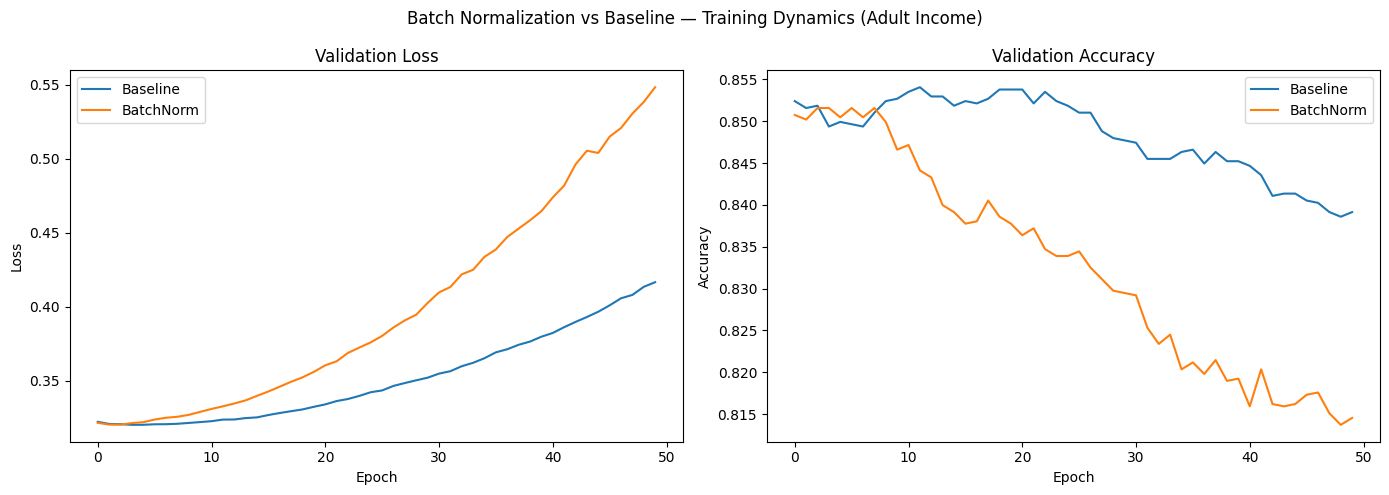

In [42]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history_base.history['val_loss'],label='Baseline')
plt.plot(history_bn.history['val_loss'],label='BatchNorm')

plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['val_accuracy'],label='Baseline')
plt.plot(history_bn.history['val_accuracy'],label='BatchNorm')

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle(
    'Batch Normalization vs Baseline — '
    'Training Dynamics (Adult Income)'
)

plt.tight_layout()
plt.show()

In [43]:
bn_layer = model_bn.layers[1]

gamma, beta, moving_mean, moving_variance = (
    bn_layer.get_weights()
)

print('Gamma shape:', gamma.shape)
print('Beta shape :', beta.shape)

Gamma shape: (128,)
Beta shape : (128,)


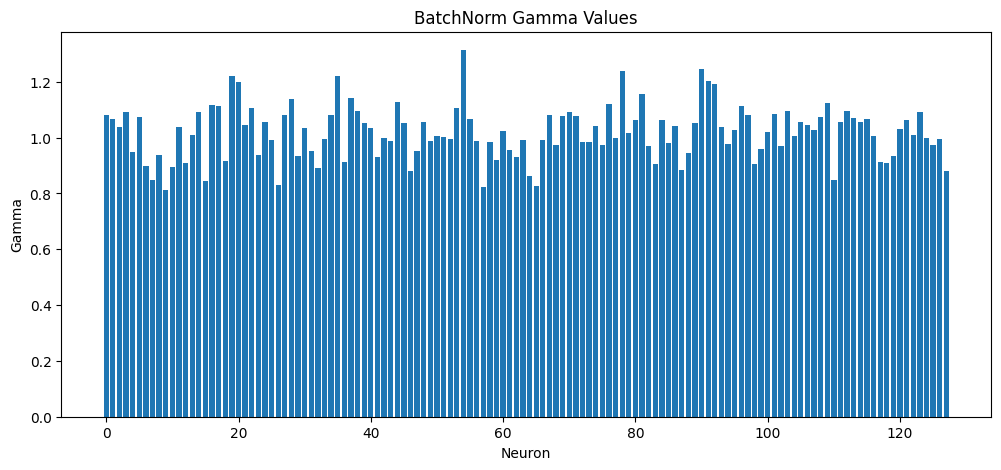

In [44]:
plt.figure(figsize=(12, 5))
plt.bar(range(len(gamma)),gamma)
plt.title('BatchNorm Gamma Values')
plt.xlabel('Neuron')
plt.ylabel('Gamma')
plt.show()

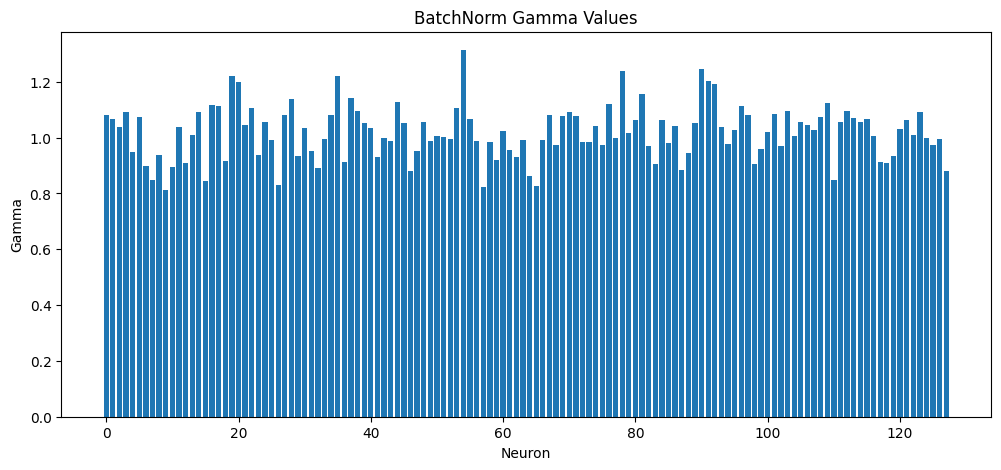

In [45]:
plt.figure(figsize=(12, 5))
plt.bar(range(len(gamma)),gamma)
plt.title('BatchNorm Gamma Values')
plt.xlabel('Neuron')
plt.ylabel('Gamma')
plt.show()

**Task 7: Optimizers — Convergence & Final Comparison**

-  Build 5 models with different optimisers

In [47]:
optimizers = {
    'SGD':keras.optimizers.SGD(),
    'SGD Momentum':keras.optimizers.SGD(learning_rate=0.01,momentum=0.9),
    'RMSprop':keras.optimizers.RMSprop(),
    'Adam':keras.optimizers.Adam(),
    'Adam Explicit':keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)
}

optimizer_models = {}
optimizer_histories = {}

for name, optimizer in optimizers.items():

    print("\nTraining:", name)

    model = build_ann(
        input_dim=X_train.shape[1],
        activation='relu',
        initializer='he_normal',
        use_batch_norm=True,
        optimizer=optimizer,
        loss='binary_crossentropy'
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    optimizer_models[name] = model
    optimizer_histories[name] = history

    print("Final validation accuracy:",history.history['val_accuracy'][-1])


Training: SGD
Final validation accuracy: 0.8501935005187988

Training: SGD Momentum
Final validation accuracy: 0.8220010995864868

Training: RMSprop
Final validation accuracy: 0.8275290131568909

Training: Adam
Final validation accuracy: 0.8261470198631287

Training: Adam Explicit
Final validation accuracy: 0.817855179309845


 Optimiser convergence plot

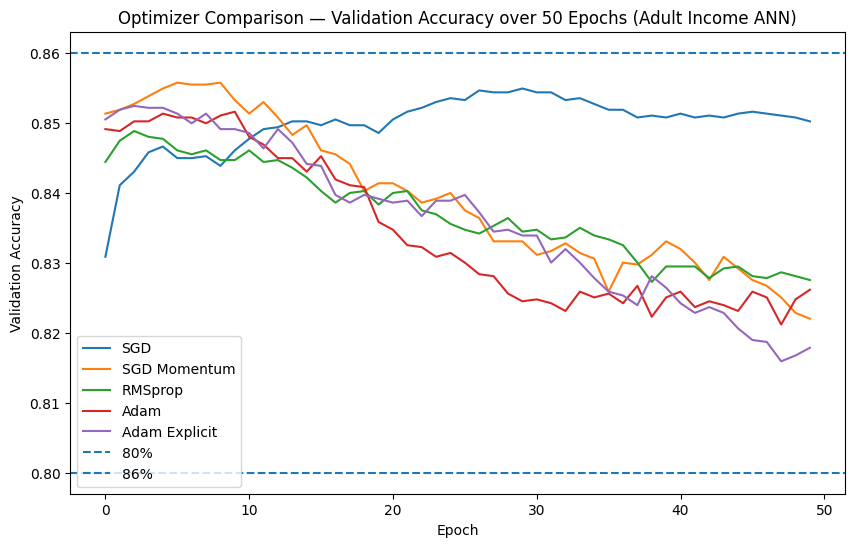

In [48]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(history.history['val_accuracy'],label=name)

plt.axhline(0.80,linestyle='--',label='80%')
plt.axhline(0.86,linestyle='--',label='86%')
plt.title('Optimizer Comparison — Validation Accuracy ''over 50 Epochs (Adult Income ANN)')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

Final Combined ANN — best configuration

In [49]:
final_model = build_ann(
    input_dim=X_train.shape[1],
    hidden_units=[128, 64],
    activation='relu',
    initializer='he_normal',
    use_batch_norm=True,
    optimizer='adam',
    loss='binary_crossentropy'
)

history_final = final_model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7940 - loss: 0.4068 - val_accuracy: 0.7980 - val_loss: 0.3925
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8083 - loss: 0.3766 - val_accuracy: 0.7993 - val_loss: 0.3912
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8126 - loss: 0.3677 - val_accuracy: 0.7985 - val_loss: 0.3939
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8155 - loss: 0.3613 - val_accuracy: 0.7968 - val_loss: 0.3967
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8190 - loss: 0.3558 - val_accuracy: 0.7971 - val_loss: 0.3984
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8212 - loss: 0.3506 - val_accuracy: 0.7938 - val_loss: 0.4003
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8240 - loss: 0.3455 - val_accuracy: 0.7949 - val_loss: 0.4017
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8263 - loss: 0.3406 - val_accuracy: 0.

In [50]:
final_prob = final_model.predict(X_test,verbose=0).flatten()
final_pred = (final_prob > 0.5).astype(int)
final_accuracy = accuracy_score(y_test,final_pred)
final_precision = precision_score(y_test,final_pred)
final_recall = recall_score(y_test,final_pred)
final_f1 = f1_score(y_test,final_pred)
final_auc = roc_auc_score(y_test,final_prob)

print('Final Model Results')
print('-------------------')
print('Accuracy :', final_accuracy)
print('Precision:', final_precision)
print('Recall   :', final_recall)
print('F1 Score :', final_f1)
print('ROC-AUC  :', final_auc)

Final Model Results
-------------------
Accuracy : 0.7872857932559425
Precision: 0.5543403964456596
Recall   : 0.7234611953612846
F1 Score : 0.6277089783281734
ROC-AUC  : 0.856241467694829


 Full results comparison table

In [51]:
def evaluate_model(model, X_test, y_test):

    probability = model.predict(
        X_test,
        verbose=0
    ).flatten()

    prediction = (
        probability > 0.5
    ).astype(int)

    return {
        'Test Acc':
            accuracy_score(y_test, prediction),

        'Prec(1)':
            precision_score(y_test, prediction),

        'Recall(1)':
            recall_score(y_test, prediction),

        'F1(1)':
            f1_score(y_test, prediction),

        'ROC-AUC':
            roc_auc_score(y_test, probability)
    }

results = []

metrics = evaluate_model(model_base,X_test,y_test)

results.append({
    'Model': 'Baseline',
    'Activation': 'ReLU',
    'Init': 'Glorot Uniform',
    'Loss': 'BCE',
    'BatchNorm': 'No',
    'Optimizer': 'Adam',
    **metrics
})

In [52]:
metrics = evaluate_model(model_wbce,X_test,y_test)

results.append({
    'Model': 'Weighted BCE',
    'Activation': 'ReLU',
    'Init': 'He Normal',
    'Loss': 'Weighted BCE',
    'BatchNorm': 'No',
    'Optimizer': 'Adam',
    **metrics
})

metrics = evaluate_model(model_focal,X_test,y_test)

results.append({
    'Model': 'Focal Loss',
    'Activation': 'ReLU',
    'Init': 'He Normal',
    'Loss': 'Focal Loss',
    'BatchNorm': 'No',
    'Optimizer': 'Adam',
    **metrics
})
metrics = evaluate_model(model_bn,X_test,y_test)

results.append({
    'Model': 'BatchNorm',
    'Activation': 'ReLU',
    'Init': 'He Normal',
    'Loss': 'BCE',
    'BatchNorm': 'Yes',
    'Optimizer': 'Adam',
    **metrics
})

metrics = evaluate_model(final_model,X_test,y_test)

results.append({
    'Model': 'Final Combined',
    'Activation': 'ReLU',
    'Init': 'He Normal',
    'Loss': 'Weighted BCE',
    'BatchNorm': 'Yes',
    'Optimizer': 'Adam',
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Baseline,ReLU,Glorot Uniform,BCE,No,Adam,0.834826,0.694387,0.595897,0.641383,0.881993
1,Weighted BCE,ReLU,He Normal,Weighted BCE,No,Adam,0.796130,0.561725,0.807761,0.662642,0.884437
2,Focal Loss,ReLU,He Normal,Focal Loss,No,Adam,0.818021,0.770417,0.378680,0.507775,0.879491
3,BatchNorm,ReLU,He Normal,BCE,Yes,Adam,0.816252,0.658991,0.536128,0.591244,0.867330
4,Final Combined,ReLU,He Normal,Weighted BCE,Yes,Adam,0.787286,0.554340,0.723461,0.627709,0.856241
